In [ ]:
# Cell 1: Environment Setup + Drive Mount


!pip install transformers datasets scikit-learn pandas numpy \
             matplotlib seaborn emoji wordsegment tqdm \
             --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, os, io, json, pickle, warnings, unicodedata, shutil, time
from collections import Counter
warnings.filterwarnings("ignore")

# Consistent visual style for ALL thesis figures
plt.rcParams.update({
    "figure.dpi"        : 150,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "font.family"       : "DejaVu Sans",
})
DISASTER_COLOR   = "#D85A30"   # coral  — disaster class
NODISASTER_COLOR = "#1D9E75"   # teal   — non-disaster class
NEUTRAL_COLOR    = "#7F77DD"   # purple — neutral / combined

# NLTK downloads
import nltk
for pkg in ["punkt", "stopwords", "wordnet"]:
    nltk.download(pkg, quiet=True)

# Wordsegment for hashtag expansion
import wordsegment
wordsegment.load()

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

DRIVE_STAGE1_DIR = "/content/drive/MyDrive/Thesis_Stage1"
os.makedirs(DRIVE_STAGE1_DIR, exist_ok=True)

def save_to_drive(local_path, label=""):
    """Copy a local file to the Stage 1 Drive folder."""
    dest = os.path.join(DRIVE_STAGE1_DIR, os.path.basename(local_path))
    shutil.copy2(local_path, dest)
    print(f"  ✓ {os.path.basename(local_path)} → Drive  {label}")

import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
else:
    print(f"  (CPU — Stage 1 does not require GPU)")

print(f"\n✓ Drive mounted → {DRIVE_STAGE1_DIR}")
print("✓ Cell 1 complete — environment ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 61.0 MB/s eta 0:00:00
Mounted at /content/drive
Device : cpu
  (CPU — Stage 1 does not require GPU)

✓ Drive mounted → /content/drive/MyDrive/Thesis_Stage1
✓ Cell 1 complete — environment ready


In [ ]:
# ===== Cell 2: Load CrisisBench =====
# Dataset : QCRI/CrisisBench-english
# Two configs: 'informativeness' (binary) + 'humanitarian' (type)
# We load both so we can merge binary label + type label on tweet_id

from datasets import load_dataset

def load_crisisb_config(config_name):
    """Load one CrisisBench config, trying both API styles."""
    try:
        ds = load_dataset("QCRI/CrisisBench-english", config_name,
                          trust_remote_code=True)
    except Exception:
        ds = load_dataset("QCRI/CrisisBench-english", config_name)
    dfs = []
    for split_name, split_data in ds.items():
        tmp = split_data.to_pandas()
        tmp["_split"] = split_name
        dfs.append(tmp)
    return pd.concat(dfs, ignore_index=True)

print("Loading CrisisBench — 'informativeness' config …")
cb_info_df = load_crisisb_config("informativeness")
print(f"  ✓ {len(cb_info_df):,} rows  |  columns: {list(cb_info_df.columns)}")

print("\nLoading CrisisBench — 'humanitarian' config …")
cb_human_df = load_crisisb_config("humanitarian")
print(f"  ✓ {len(cb_human_df):,} rows  |  columns: {list(cb_human_df.columns)}")

print("\n✓ Cell 2 complete")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'QCRI/CrisisBench-english' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'QCRI/CrisisBench-english' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading CrisisBench — 'informativeness' config …


README.md: 0.00B [00:00, ?B/s]

informativeness/test.json:   0%|          | 0.00/10.6M [00:00<?, ?B/s]

informativeness/dev.json:   0%|          | 0.00/5.44M [00:00<?, ?B/s]

...

humanitarian/train.json:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/17365 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/8957 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/61235 [00:00<?, ? examples/s]

  ✓ 87,557 rows  |  columns: ['id', 'event', 'source', 'text', 'lang', 'lang_conf', 'class_label', '_split']

✓ Cell 2 complete


In [ ]:
merged["label_type"] = merged["label_type"].fillna("unknown")
merged["source"]     = "crisisb"

# This is used in Stage 2 LOTO type mapping — essential for reproducibility

# Initialize 'event' column to 'unknown' in case it cannot be merged from either source
merged["event"] = "unknown"

# Attempt to get 'event' from cb_info_df
if event_col and event_col in cb_info_df.columns:
    # Extract unique ID and event from cb_info_df to prevent row explosion during merge
    event_from_info = cb_info_df[[info_id_col, event_col]].drop_duplicates(subset=[info_id_col])
    # Merge this event data into 'merged'. Use suffixes to manage column naming if 'event' already exists.
    merged_temp = merged.merge(event_from_info, on=info_id_col, how="left", suffixes=('', '_from_info'))
    # Update the 'event' column in 'merged' with values from 'event_from_info' where available,
    # otherwise keep the existing value (which defaults to 'unknown').
    merged['event'] = merged_temp[event_col + '_from_info'].fillna(merged_temp['event'])
    # Drop the temporary merged column
    merged = merged_temp.drop(columns=[event_col + '_from_info'], errors='ignore')

# Attempt to get 'event' from cb_human_df (only if not already found in cb_info_df)
elif event_col and event_col in cb_human_df.columns:
    # Prepare humanitarian event data for merging
    event_from_human = cb_human_df[[human_id_col, event_col]].drop_duplicates(subset=[human_id_col]).rename(
        columns={human_id_col: info_id_col}) # Rename ID column for consistent merging
    try:
        # Merge this event data into 'merged' with suffixes
        merged_temp = merged.merge(event_from_human, on=info_id_col, how="left", suffixes=('', '_from_human'))
        # Update 'event' column, prioritizing new data, falling back to existing 'unknown'
        merged['event'] = merged_temp[event_col + '_from_human'].fillna(merged_temp['event'])
        # Drop the temporary merged column
        merged = merged_temp.drop(columns=[event_col + '_from_human'], errors='ignore')
    except Exception:
        # If merge fails, 'event' remains 'unknown' as initialized, so no action needed here.
        pass

crisisb_df = merged[["text", "label_binary", "label_type", "source", "event"]].copy()
crisisb_df = crisisb_df.dropna(subset=["text"])
crisisb_df = crisisb_df[crisisb_df["text"].str.strip() != ""].reset_index(drop=True)

print(f"\n  CrisisBench final : {len(crisisb_df):,} rows")
print(f"    Disaster     (1): {crisisb_df['label_binary'].sum():,}")
print(f"    Non-disaster (0): {(crisisb_df['label_binary']==0).sum():,}")
print(f"    Label types     : {crisisb_df['label_type'].nunique()} unique")
print(f"    Events          : {crisisb_df['event'].nunique()} unique")
print("\n✓ Cell 3 complete")


  CrisisBench final : 156,901 rows
    Disaster     (1): 94,046
    Non-disaster (0): 62,855
    Label types     : 12 unique
    Events          : 1 unique

✓ Cell 3 complete


In [ ]:
# ===== Cell 4: Load + Standardise HumAID =====
# Dataset : QCRI/HumAID-all — ~77K tweets, 11 humanitarian categories, 19 events
#
# Label mapping: "not_humanitarian" >> 0 (non-disaster), all others >> 1 (disaster)

print("Loading HumAID …")
print("~1–2 minutes\n")

def load_humaid():
    # Primary: HuggingFace datasets library
    try:
        ds = load_dataset("QCRI/HumAID-all", trust_remote_code=True)
        dfs = []
        for split, data in ds.items():
            tmp = data.to_pandas(); tmp["_split"] = split; dfs.append(tmp)
        df = pd.concat(dfs, ignore_index=True)
        print(f"  ✓ Loaded via datasets library: {len(df):,} rows")
        return df
    except Exception as e:
        print(f"  datasets library failed ({e})")

    # Fallback: direct parquet URLs
    print("  Trying direct parquet URLs …")
    import urllib.request
    URLS = {
        "train": ("https://huggingface.co/datasets/QCRI/HumAID-all/"
                  "resolve/main/data/train-00000-of-00001.parquet"),
        "test" : ("https://huggingface.co/datasets/QCRI/HumAID-all/"
                  "resolve/main/data/test-00000-of-00001.parquet"),
    }
    dfs = []
    for split_name, url in URLS.items():
        try:
            req = urllib.request.Request(url,
                  headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as r:
                raw = r.read()
            tmp = pd.read_parquet(io.BytesIO(raw))
            tmp["_split"] = split_name
            dfs.append(tmp)
            print(f"    ✓ {split_name}: {len(tmp):,} rows")
        except Exception as e2:
            print(f"    ✗ {split_name} failed: {e2}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

humaid_raw = load_humaid()

# Standardise column names
HA_TEXT_COL  = next(
    (c for c in ["tweet_text", "text"] if c in humaid_raw.columns),
    humaid_raw.columns[0])
HA_LABEL_COL = next(
    (c for c in ["class_label", "label", "label_type"] if c in humaid_raw.columns),
    None)

NON_DISASTER_HUMAID = {"not_humanitarian"}

humaid_raw["label_binary"] = humaid_raw[HA_LABEL_COL].apply(
    lambda x: 0 if str(x).strip().lower() in NON_DISASTER_HUMAID else 1
)
humaid_raw["label_type"] = humaid_raw[HA_LABEL_COL].astype(str)
humaid_raw["text"]       = humaid_raw[HA_TEXT_COL].astype(str)
humaid_raw["source"]     = "humaid"
humaid_raw["event"]      = "unknown"   # HumAID has event info but no single event col

humaid_df = humaid_raw[["text", "label_binary", "label_type",
                         "source", "event"]].copy()
humaid_df = humaid_df.dropna(subset=["text"]).reset_index(drop=True)

print(f"\n  HumAID standardised: {len(humaid_df):,} rows")
print(f"    Disaster     (1): {humaid_df['label_binary'].sum():,}")
print(f"    Non-disaster (0): {(humaid_df['label_binary']==0).sum():,}")
print(f"    Label types: {list(humaid_df['label_type'].unique()[:5])} …")
print("\n✓ Cell 4 complete")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'QCRI/HumAID-all' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'QCRI/HumAID-all' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading HumAID …
⏳ ~1–2 minutes



README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.05M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.44M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/53531 [00:00<?, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split:   0%|          | 0/15160 [00:00<?, ? examples/s]

  datasets library failed ({'dev'})
  Trying direct parquet URLs …
    ✓ train: 53,531 rows
    ✓ test: 15,160 rows

  HumAID standardised: 68,691 rows
    Disaster     (1): 63,039
    Non-disaster (0): 5,652
    Label types: ['injured_or_dead_people', 'rescue_volunteering_or_donation_effort', 'sympathy_and_support', 'infrastructure_and_utility_damage', 'requests_or_urgent_needs'] …

✓ Cell 4 complete


In [ ]:
# ===== Cell 5: Combine + Deduplicate =====
# Merge CrisisBench + HumAID into one unified DataFrame
# Drop exact text duplicates (keep first, preserves original label)

print("=" * 55)
print("Combining datasets")
print("=" * 55)

df_combined = pd.concat([crisisb_df, humaid_df], ignore_index=True)
print(f"  Total before dedup : {len(df_combined):,}")

# Remove empty texts
df_combined = df_combined[df_combined["text"].str.strip() != ""].copy()

# Drop exact text duplicates
n_before = len(df_combined)
df_combined = df_combined.drop_duplicates(
    subset=["text"], keep="first").reset_index(drop=True)
n_removed = n_before - len(df_combined)

print(f"  Duplicates removed : {n_removed:,}")
print(f"  Total after dedup  : {len(df_combined):,}")

print(f"\n  Breakdown by source:")
print(df_combined["source"].value_counts().to_string())

print(f"\n  Class balance:")
counts = df_combined["label_binary"].value_counts().sort_index()
for cls, label in zip([0,1], ["Non-disaster (0)", "Disaster (1)"]):
    n = counts.get(cls, 0)
    print(f"    {label}: {n:,}  ({n/len(df_combined)*100:.1f}%)")

print("\n✓ Cell 5 complete")

Combining datasets
  Total before dedup : 225,592
  Duplicates removed : 3
  Total after dedup  : 225,589

  Breakdown by source:
source
crisisb    156899
humaid      68690

  Class balance:
    Non-disaster (0): 68,505  (30.4%)
    Disaster (1): 157,084  (69.6%)

✓ Cell 5 complete


In [ ]:
# ===== Cell 6: Preprocessing Pipeline =====
# Defines preprocess_text() — the canonical preprocessing function.
# THIS FUNCTION IS REUSED VERBATIM IN STAGE 2 AND STAGE 3.
#
# Steps (in order):
#   1. Unicode NFKC normalisation
#   2. Remove retweet prefix (RT @user:)
#   3. Replace URLs with [URL]
#   4. Replace @mentions with @USER
#   5. Segment hashtags (#PrayForNepal → "pray for nepal")
#   6. Convert emojis to text tokens (🔥 → fire)
#   7. Lowercase
#   8. Collapse whitespace
#
# Deliberately NOT removed: punctuation, numbers, stopwords
# Reason: DistilBERT/RoBERTa handle these natively via subword tokenisation

import emoji as emoji_lib
from wordsegment import segment

# Compile patterns once for performance
_RE_RT      = re.compile(r"^RT\s+@\w+:\s*")
_RE_URL     = re.compile(r"https?://\S+|www\.\S+")
_RE_MENTION = re.compile(r"@\w+")
_RE_HASHTAG = re.compile(r"#(\w+)")
_RE_SPACES  = re.compile(r"\s+")

def preprocess_text(text: str) -> str:
    """
    Standardised preprocessing for disaster tweet text.
    Identical across Stage 1, Stage 2, and Stage 3.

    Args:
        text: raw tweet string

    Returns:
        cleaned string, lowercased, with [URL] and @USER placeholders
    """
    if not isinstance(text, str):
        text = str(text)

    # 1. Unicode normalisation
    text = unicodedata.normalize("NFKC", text)

    # 2. Remove retweet prefix
    text = _RE_RT.sub("", text)

    # 3. Replace URLs
    text = _RE_URL.sub("[URL]", text)

    # 4. Replace @mentions
    text = _RE_MENTION.sub("@USER", text)

    # 5. Hashtag segmentation
    def _expand_hashtag(match):
        words = segment(match.group(1))
        return " ".join(words) if words else match.group(1)
    text = _RE_HASHTAG.sub(_expand_hashtag, text)

    # 6. Emoji → descriptive text token
    text = emoji_lib.demojize(text, delimiters=(" ", " "))

    # 7. Lowercase
    text = text.lower()

    # 8. Collapse whitespace
    text = _RE_SPACES.sub(" ", text).strip()

    return text


# Sanity check
TEST_TWEETS = [
    "RT @BBCBreaking: Massive earthquake hits Nepal #PrayForNepal 🙏 http://t.co/abc",
    "#wildfireCA is spreading fast!!! 🔥🔥 @CAL_FIRE please help!!",
    "Just had coffee ☕ what a beautiful morning",
]
print("Preprocessing sanity check:")
print("-" * 60)
for t in TEST_TWEETS:
    print(f"  IN : {t}")
    print(f"  OUT: {preprocess_text(t)}")
    print()

print("✓ Cell 6 complete — preprocess_text() defined and tested")

Preprocessing sanity check:
------------------------------------------------------------
  IN : RT @BBCBreaking: Massive earthquake hits Nepal #PrayForNepal 🙏 http://t.co/abc
  OUT: massive earthquake hits nepal pray for nepal folded_hands [url]

  IN : #wildfireCA is spreading fast!!! 🔥🔥 @CAL_FIRE please help!!
  OUT: wildfire ca is spreading fast!!! fire fire @user please help!!

  IN : Just had coffee ☕ what a beautiful morning
  OUT: just had coffee hot_beverage what a beautiful morning

✓ Cell 6 complete — preprocess_text() defined and tested


In [ ]:
# ===== Cell 7: Apply Preprocessing =====
# Apply preprocess_text() to all 225K+ rows

from tqdm.auto import tqdm
tqdm.pandas(desc="Preprocessing")

print("Applying preprocessing to full dataset …")

t0 = time.time()
df_combined["clean_text"] = df_combined["text"].progress_apply(preprocess_text)
elapsed = time.time() - t0

empty_after = (df_combined["clean_text"].str.strip() == "").sum()
print(f"\n✓ Preprocessing complete in {elapsed:.0f}s")
print(f"  Rows processed      : {len(df_combined):,}")
print(f"  Empty after cleaning: {empty_after}")

if empty_after > 0:
    df_combined = df_combined[
        df_combined["clean_text"].str.strip() != ""
    ].reset_index(drop=True)
    print(f"  Dropped {empty_after} empty rows → {len(df_combined):,} remaining")

# Sample check
print("\nSample preprocessed rows:")
sample = df_combined[["text","clean_text","label_binary","source"]].sample(
    3, random_state=42)
for _, row in sample.iterrows():
    print(f"  [{row['source']}] [{row['label_binary']}]")
    print(f"    RAW  : {row['text'][:90]}")
    print(f"    CLEAN: {row['clean_text'][:90]}")
    print()

print("✓ Cell 7 complete")


Applying preprocessing to full dataset …
⏳ Expected: 4–8 minutes (hashtag segmentation)



Preprocessing:   0%|          | 0/225589 [00:00<?, ?it/s]


✓ Preprocessing complete in 233s
  Rows processed      : 225,589
  Empty after cleaning: 0

Sample preprocessed rows:
  [crisisb] [0]
    RAW  : Did you hear what our MP RamGopal Yadav has to say about #NepalEarthquake?
    CLEAN: did you hear what our mp ramgopal yadav has to say about nepal earthquake?

  [crisisb] [1]
    RAW  : Will the remnants of #MariaHurricane #Maria impact the #unitedkingdom #UK https://t.co/CID
    CLEAN: will the remnants of maria hurricane maria impact the united kingdom uk [url] [url]

  [crisisb] [1]
    RAW  : Hi Ellen can u support the flood victims in Australia we love you
    CLEAN: hi ellen can u support the flood victims in australia we love you

✓ Cell 7 complete


In [ ]:
# ===== Cell 8: LOTO Disaster Type Mapping =====
# Builds the 'disaster_type' column used for Leave-One-Type-Out (LOTO)
# evaluation in Stage 2.
#
# Strategy:
#   CrisisBench: map from 'event' column (e.g. "2015_nepal_earthquake" → "earthquake")
#   HumAID:      all → "other" (no explicit disaster type in HumAID schema)
#
# If 'event' column is "unknown" (CrisisBench API didn't return it),
# we re-fetch from HuggingFace here to ensure LOTO is reproducible.

print("=" * 55)
print("LOTO Disaster Type Mapping")
print("=" * 55)

EVENT_TO_TYPE = {
    "earthquake"  : "earthquake",
    "quake"       : "earthquake",
    "flood"       : "flood",
    "floods"      : "flood",
    "hurricane"   : "hurricane",
    "cyclone"     : "hurricane",
    "typhoon"     : "hurricane",
    "wildfire"    : "fire",
    "fire"        : "fire",
    "explosion"   : "explosion",
    "bombing"     : "explosion",
    "bombings"    : "explosion",
    "shooting"    : "explosion",
}

def infer_type_from_event(event_str):
    """Map event name string to disaster type category."""
    e = str(event_str).lower()
    for key, dtype in EVENT_TO_TYPE.items():
        if key in e:
            return dtype
    return "other"

# Check if we already have useful event data
n_unknown_events = (df_combined["event"] == "unknown").sum()
print(f"  Rows with event='unknown': {n_unknown_events:,}")

if n_unknown_events > len(df_combined) * 0.5:
    # More than half are unknown — re-fetch CrisisBench event column
    print("  Re-fetching CrisisBench event column from HuggingFace …")
    try:
        cb_events_ds = load_dataset(
            "QCRI/CrisisBench-english", "informativeness",
            trust_remote_code=True
        )
        ev_dfs = []
        for split, data in cb_events_ds.items():
            tmp = data.to_pandas()
            if find_col(tmp, EVENT_CANDS):
                ec = find_col(tmp, EVENT_CANDS)
                tc = find_col(tmp, TEXT_CANDS)
                ev_dfs.append(tmp[[tc, ec]].rename(
                    columns={tc: "text", ec: "event"}))
        if ev_dfs:
            event_lookup = pd.concat(ev_dfs, ignore_index=True)
            event_lookup = event_lookup.drop_duplicates("text")
            event_lookup["event"] = event_lookup["event"].fillna("unknown")
            # Merge back
            df_combined = df_combined.merge(
                event_lookup.rename(columns={"event": "_event_new"}),
                on="text", how="left"
            )
            mask = (df_combined["event"] == "unknown") & \
                   df_combined["_event_new"].notna()
            df_combined.loc[mask, "event"] = df_combined.loc[mask, "_event_new"]
            df_combined = df_combined.drop(columns=["_event_new"])
            print(f"  ✓ Re-fetched event data")
    except Exception as e:
        print(f"  ⚠ Re-fetch failed ({e}) — using text-based inference")

# Map to disaster type
df_combined["disaster_type"] = df_combined["event"].apply(infer_type_from_event)
# HumAID rows: keep as "other"
df_combined.loc[df_combined["source"] == "humaid", "disaster_type"] = "other"

type_dist = df_combined["disaster_type"].value_counts()
print(f"\n  Disaster type distribution:")
for dtype, count in type_dist.items():
    pct = count / len(df_combined) * 100
    warn = " ⚠ small" if count < 5000 else ""
    print(f"    {dtype:<15}: {count:>8,}  ({pct:.1f}%){warn}")

print("\n✓ Cell 8 complete — LOTO type mapping done")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'QCRI/CrisisBench-english' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'QCRI/CrisisBench-english' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


LOTO Disaster Type Mapping
  Rows with event='unknown': 225,589
  Re-fetching CrisisBench event column from HuggingFace …
  ✓ Re-fetched event data

  Disaster type distribution:
    other          :  134,721  (59.7%)
    hurricane      :   35,363  (15.7%)
    flood          :   22,046  (9.8%)
    earthquake     :   19,071  (8.5%)
    explosion      :   10,992  (4.9%)
    fire           :    3,396  (1.5%) ⚠ small

✓ Cell 8 complete — LOTO type mapping done


EDA — Exploratory Data Analysis

Disaster tweets:
  Count       : 157,084
  Char length — mean=114.4  median=106  std=58.0
  Word count  — mean=19.2  median=17

Non-disaster tweets:
  Count       : 68,505
  Char length — mean=86.1  median=79  std=50.7
  Word count  — mean=15.3  median=14


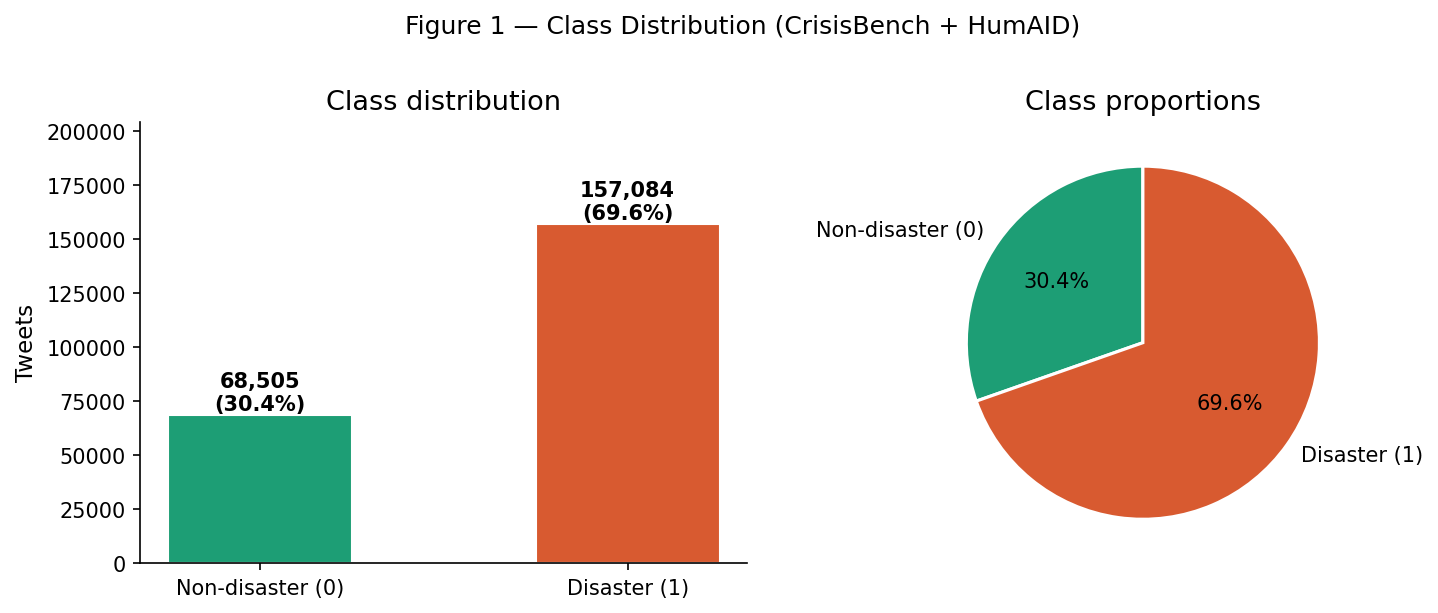

✓ Figure 1 saved


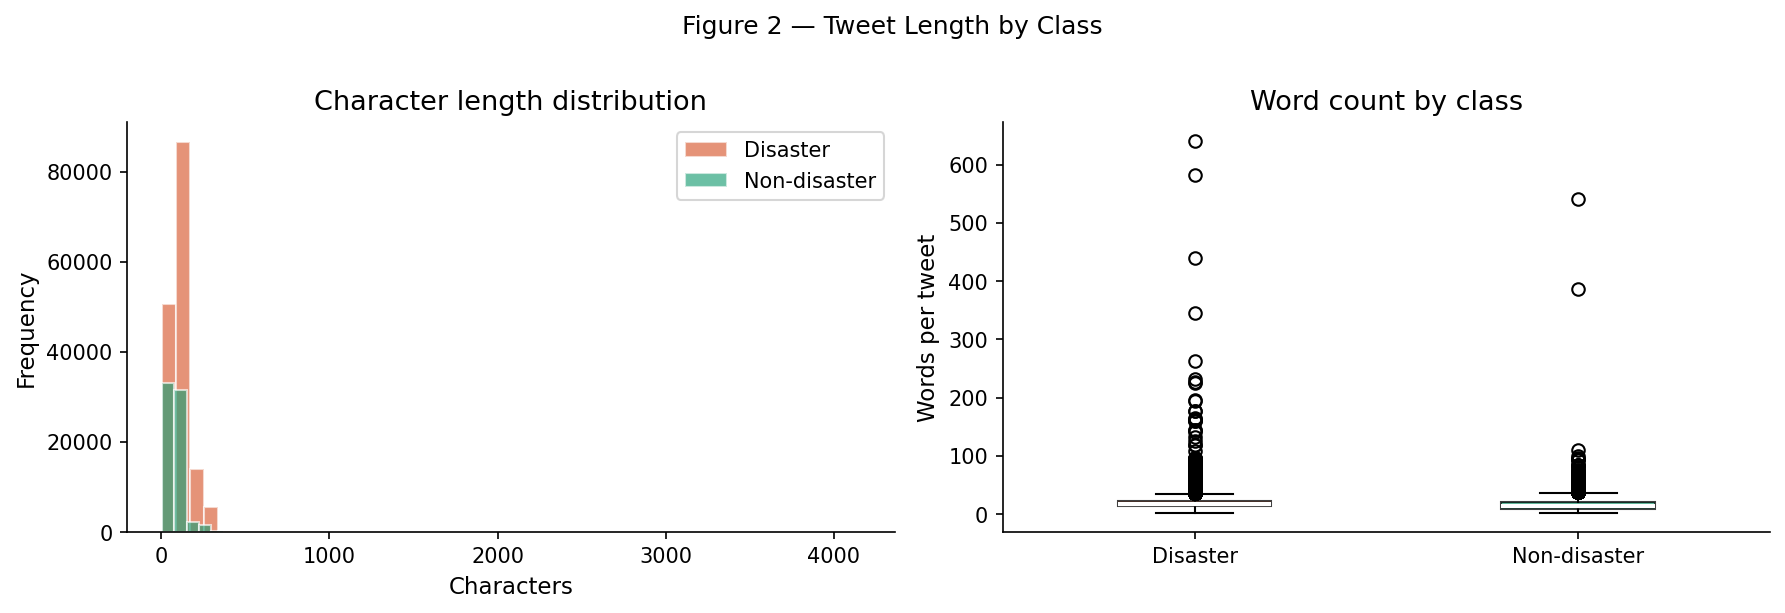

✓ Figure 2 saved


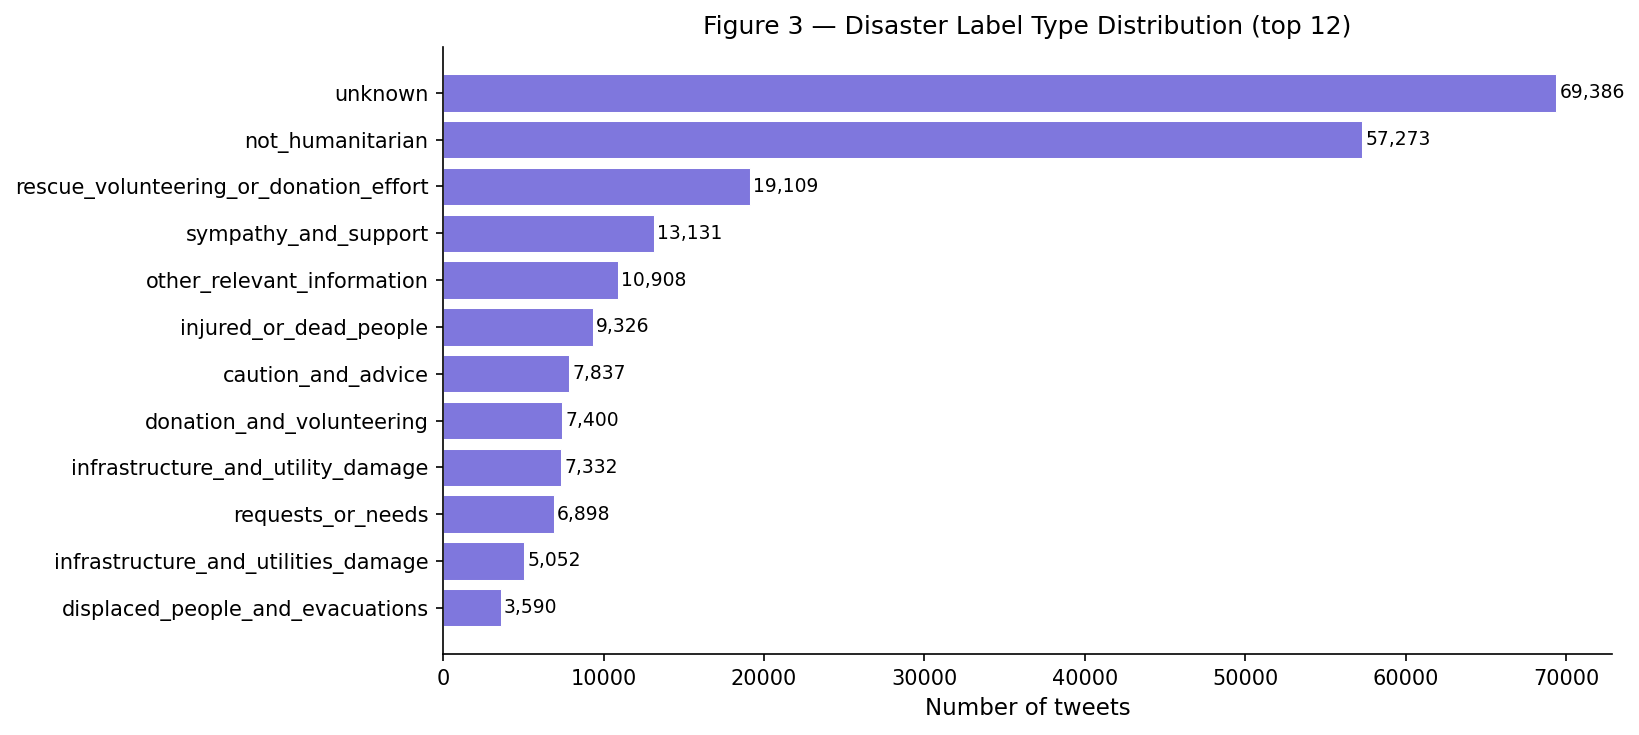

✓ Figure 3 saved


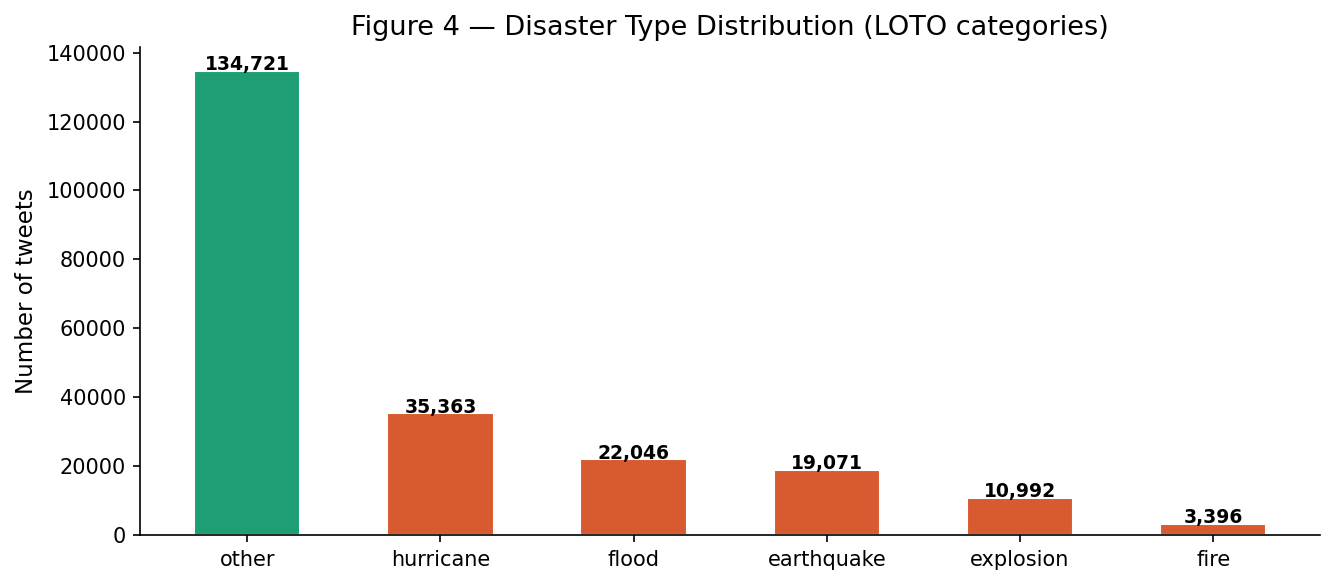

✓ Figure 4 saved

✓ Cell 9 complete — EDA done


In [ ]:
# ===== Cell 9: Exploratory Data Analysis =====
# Produces Figures 1–4 for the thesis

print("=" * 55)
print("EDA — Exploratory Data Analysis")
print("=" * 55)

df = df_combined.copy()
df["char_len"]   = df["clean_text"].str.len()
df["word_count"] = df["clean_text"].str.split().str.len()

disaster     = df[df["label_binary"] == 1]
non_disaster = df[df["label_binary"] == 0]

for subset, label in [(disaster, "Disaster"), (non_disaster, "Non-disaster")]:
    print(f"\n{label} tweets:")
    print(f"  Count       : {len(subset):,}")
    print(f"  Char length — mean={subset['char_len'].mean():.1f}  "
          f"median={subset['char_len'].median():.0f}  "
          f"std={subset['char_len'].std():.1f}")
    print(f"  Word count  — mean={subset['word_count'].mean():.1f}  "
          f"median={subset['word_count'].median():.0f}")

# Figure 1: Class distribution
counts  = df["label_binary"].value_counts().sort_index()
labels_ = ["Non-disaster (0)", "Disaster (1)"]
n_total = len(df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bars = axes[0].bar(labels_, counts.values,
                    color=[NODISASTER_COLOR, DISASTER_COLOR],
                    edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f"{val:,}\n({val/n_total*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_title("Class distribution"); axes[0].set_ylabel("Tweets")
axes[0].set_ylim(0, counts.max() * 1.3)

axes[1].pie(counts.values, labels=labels_,
            colors=[NODISASTER_COLOR, DISASTER_COLOR],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5},
            textprops={"fontsize": 10})
axes[1].set_title("Class proportions")
fig.suptitle("Figure 1 — Class Distribution (CrisisBench + HumAID)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Figure 1 saved")

# Figure 2: Tweet length by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for subset, label, color in [
    (disaster,     "Disaster",     DISASTER_COLOR),
    (non_disaster, "Non-disaster", NODISASTER_COLOR),
]:
    axes[0].hist(subset["char_len"], bins=50, alpha=0.65,
                 label=label, color=color, edgecolor="white", lw=0.3)
axes[0].set_title("Character length distribution")
axes[0].set_xlabel("Characters"); axes[0].set_ylabel("Frequency")
axes[0].legend()

bp_data = [disaster["word_count"].values, non_disaster["word_count"].values]
bplot = axes[1].boxplot(bp_data, labels=["Disaster","Non-disaster"],
                         patch_artist=True,
                         medianprops={"color":"white","linewidth":2}, widths=0.4)
for patch, color in zip(bplot["boxes"], [DISASTER_COLOR, NODISASTER_COLOR]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_title("Word count by class"); axes[1].set_ylabel("Words per tweet")
fig.suptitle("Figure 2 — Tweet Length by Class", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("fig2_tweet_length.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Figure 2 saved")

# Figure 3: Label type breakdown
type_counts = df["label_type"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(type_counts.index[::-1], type_counts.values[::-1],
               color=NEUTRAL_COLOR, edgecolor="white", lw=0.5)
for bar, val in zip(bars, type_counts.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.set_title("Figure 3 — Disaster Label Type Distribution (top 12)", fontsize=12)
ax.set_xlabel("Number of tweets")
plt.tight_layout()
plt.savefig("fig3_label_types.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Figure 3 saved")

# Figure 4: LOTO disaster type distribution
type_dist_sorted = df["disaster_type"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = [DISASTER_COLOR if t != "other" else NODISASTER_COLOR
              for t in type_dist_sorted.index]
bars = ax.bar(type_dist_sorted.index, type_dist_sorted.values,
              color=bar_colors, edgecolor="white", width=0.55)
for bar, val in zip(bars, type_dist_sorted.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Figure 4 — Disaster Type Distribution (LOTO categories)")
ax.set_ylabel("Number of tweets")
plt.tight_layout()
plt.savefig("fig4_disaster_types.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Figure 4 saved")

print("\n✓ Cell 9 complete — EDA done")

In [ ]:
# Cell 10: Train/Val/Test Split + TF-IDF
# Split: 70 / 15 / 15  stratified by label_binary
# random_state=42 fixed for full reproducibility across all stages
#
# Split indices are saved to Drive so Stage 2 and Stage 3 use
# IDENTICAL splits >> this is critical to avoid data leakage.

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

df_model = df[["clean_text","label_binary","label_type","source","disaster_type"]].copy()
X = df_model["clean_text"]
y = df_model["label_binary"]

# 70 / 15 / 15 split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1765,   # 0.1765 × 0.85 ≈ 0.15 of total
    random_state=42, stratify=y_trainval
)

print(f"Split sizes:")
print(f"  Train : {len(X_train):,}  ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Val   : {len(X_val):,}  ({len(X_val)/len(df)*100:.1f}%)")
print(f"  Test  : {len(X_test):,}  ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3).to_string())

# ── TF-IDF vectorisation ──────────────────────────────────────
print("\nFitting TF-IDF vectoriser …")
tfidf_vec = TfidfVectorizer(
    analyzer      = "word",
    ngram_range   = (1, 2),
    max_features  = 100_000,
    min_df        = 2,
    max_df        = 0.95,
    sublinear_tf  = True,
    strip_accents = "unicode",
)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_val_tfidf   = tfidf_vec.transform(X_val)
X_test_tfidf  = tfidf_vec.transform(X_test)

print(f"  TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"  TF-IDF matrix shape (test) : {X_test_tfidf.shape}")

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vec, f)
print("  ✓ tfidf_vectorizer.pkl saved locally")

print("\n✓ Cell 10 complete")


Split sizes:
  Train : 157,906  (70.0%)
  Val   : 33,844  (15.0%)
  Test  : 33,839  (15.0%)

Class balance in test set:
label_binary
1    0.696
0    0.304

Fitting TF-IDF vectoriser …
  TF-IDF matrix shape (train): (157906, 100000)
  TF-IDF matrix shape (test) : (33839, 100000)
  ✓ tfidf_vectorizer.pkl saved locally

✓ Cell 10 complete


In [ ]:
# ===== Cell 11: Baseline Models =====
# Two baselines that Stage 2 must clearly beat:
#   1. Logistic Regression + TF-IDF  (strong classical baseline)
#   2. FastText-proxy via SGD + char n-grams  (neural baseline without transformers)
#
# Both use class_weight='balanced' — no oversampling needed for text data

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_recall_curve, average_precision_score,
)

def train_and_evaluate(model, X_tr, y_tr, X_te, y_te, model_name="Model"):
    """Train a sklearn model and return a standardised results dict."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1] \
              if hasattr(model, "predict_proba") else None

    binary_f1   = f1_score(y_te, y_pred, average="binary")
    macro_f1    = f1_score(y_te, y_pred, average="macro")
    weighted_f1 = f1_score(y_te, y_pred, average="weighted")

    print(f"\n{'='*55}")
    print(f"{model_name}")
    print(f"{'='*55}")
    print(f"  Train time   : {train_time:.1f}s")
    print(f"  Binary F1    : {binary_f1:.4f}")
    print(f"  Macro F1     : {macro_f1:.4f}")
    print(f"  Weighted F1  : {weighted_f1:.4f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Non-disaster','Disaster'])}")

    return {
        "model_name" : model_name,
        "train_time" : round(train_time, 2),
        "binary_f1"  : round(binary_f1,   4),
        "macro_f1"   : round(macro_f1,    4),
        "weighted_f1": round(weighted_f1, 4),
        "y_proba"    : y_proba,
        "y_pred"     : y_pred,
        "model"      : model,
    }


# 1. Logistic Regression
lr_model = LogisticRegression(
    C=1.0, class_weight="balanced", max_iter=1000,
    solver="lbfgs", random_state=42, n_jobs=-1,
)
lr_results = train_and_evaluate(
    lr_model, X_train_tfidf, y_train, X_test_tfidf, y_test,
    model_name="Logistic Regression (TF-IDF)"
)

# 2. FastText-proxy
ft_pipe = Pipeline([
    ("vec", HashingVectorizer(
        ngram_range=(1,3), analyzer="char_wb",
        n_features=2**18, norm="l2"
    )),
    ("clf", SGDClassifier(
        loss="log_loss", class_weight="balanced",
        max_iter=100, random_state=42, n_jobs=-1
    )),
])
ft_results = train_and_evaluate(
    ft_pipe, X_train, y_train, X_test, y_test,
    model_name="FastText-proxy (char n-gram SGD)"
)

print("\n✓ Cell 11 complete — baseline models trained")


Logistic Regression (TF-IDF)
  Train time   : 4.6s
  Binary F1    : 0.9002
  Macro F1     : 0.8481
  Weighted F1  : 0.8686

              precision    recall  f1-score   support

Non-disaster       0.74      0.86      0.80     10276
    Disaster       0.93      0.87      0.90     23563

    accuracy                           0.87     33839
   macro avg       0.84      0.86      0.85     33839
weighted avg       0.88      0.87      0.87     33839


FastText-proxy (char n-gram SGD)
  Train time   : 34.2s
  Binary F1    : 0.8449
  Macro F1     : 0.7683
  Weighted F1  : 0.7984

              precision    recall  f1-score   support

Non-disaster       0.63      0.76      0.69     10276
    Disaster       0.89      0.81      0.84     23563

    accuracy                           0.79     33839
   macro avg       0.76      0.78      0.77     33839
weighted avg       0.81      0.79      0.80     33839


✓ Cell 11 complete — baseline models trained


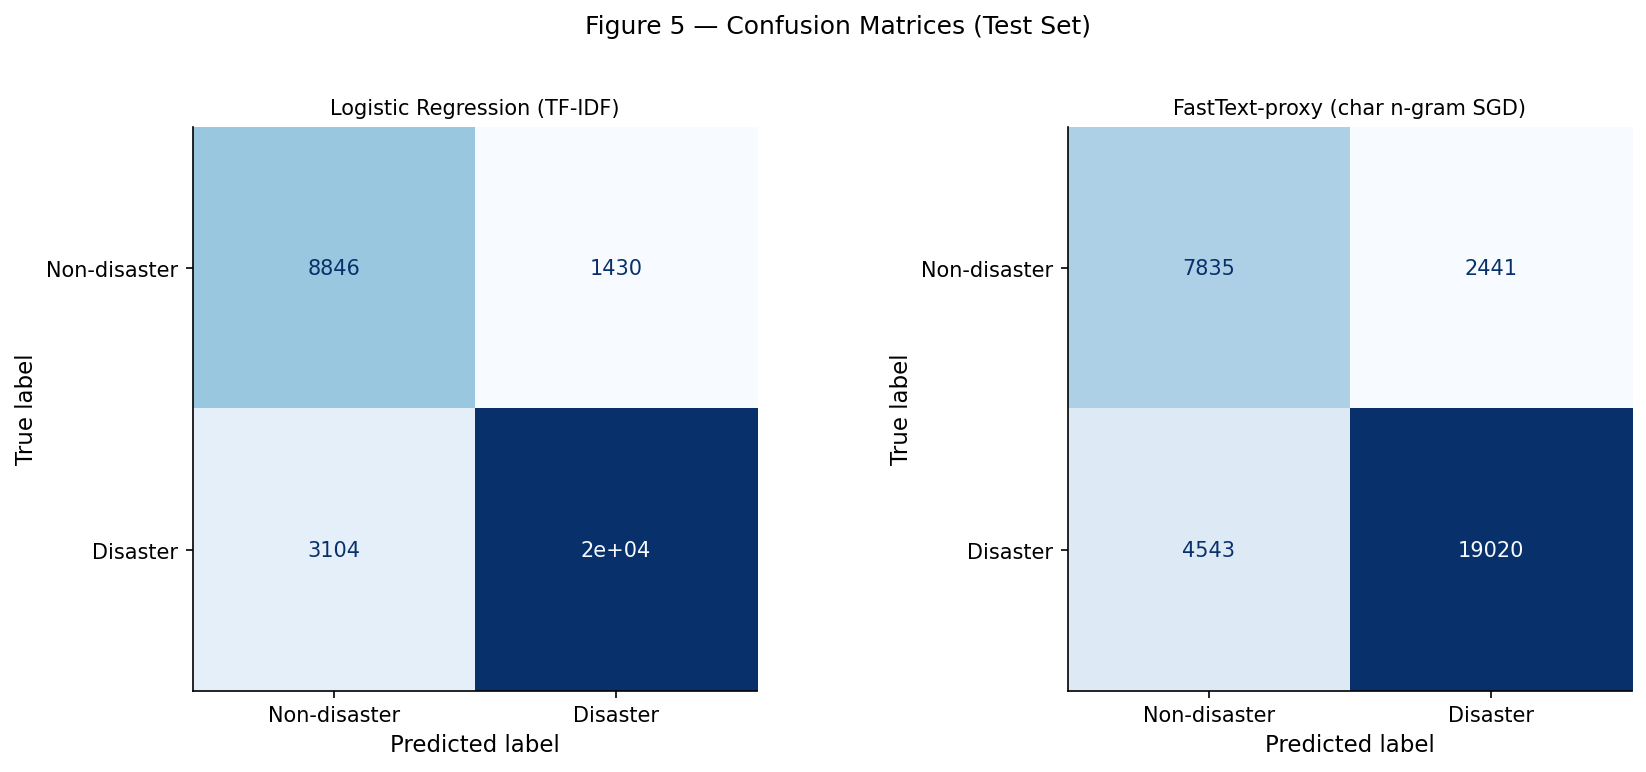

✓ Figure 5 saved


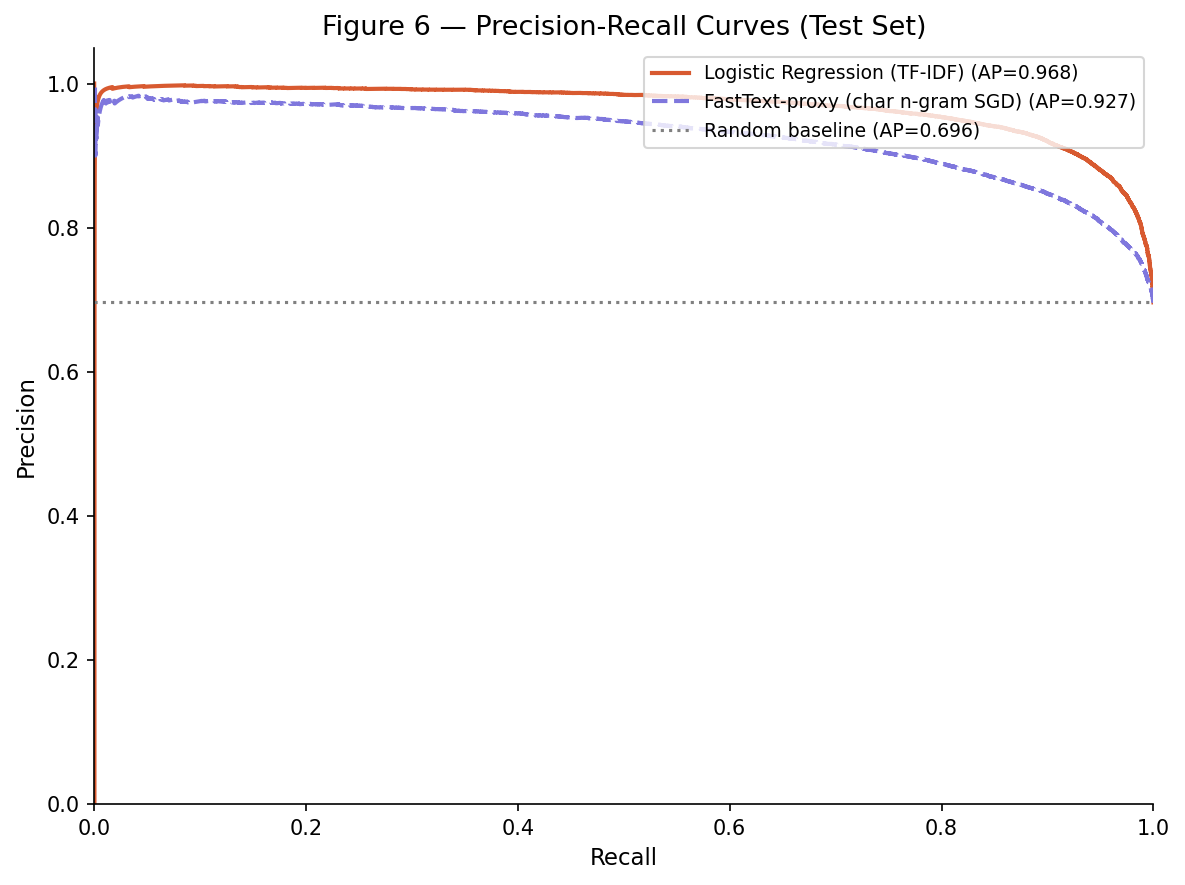

✓ Figure 6 saved


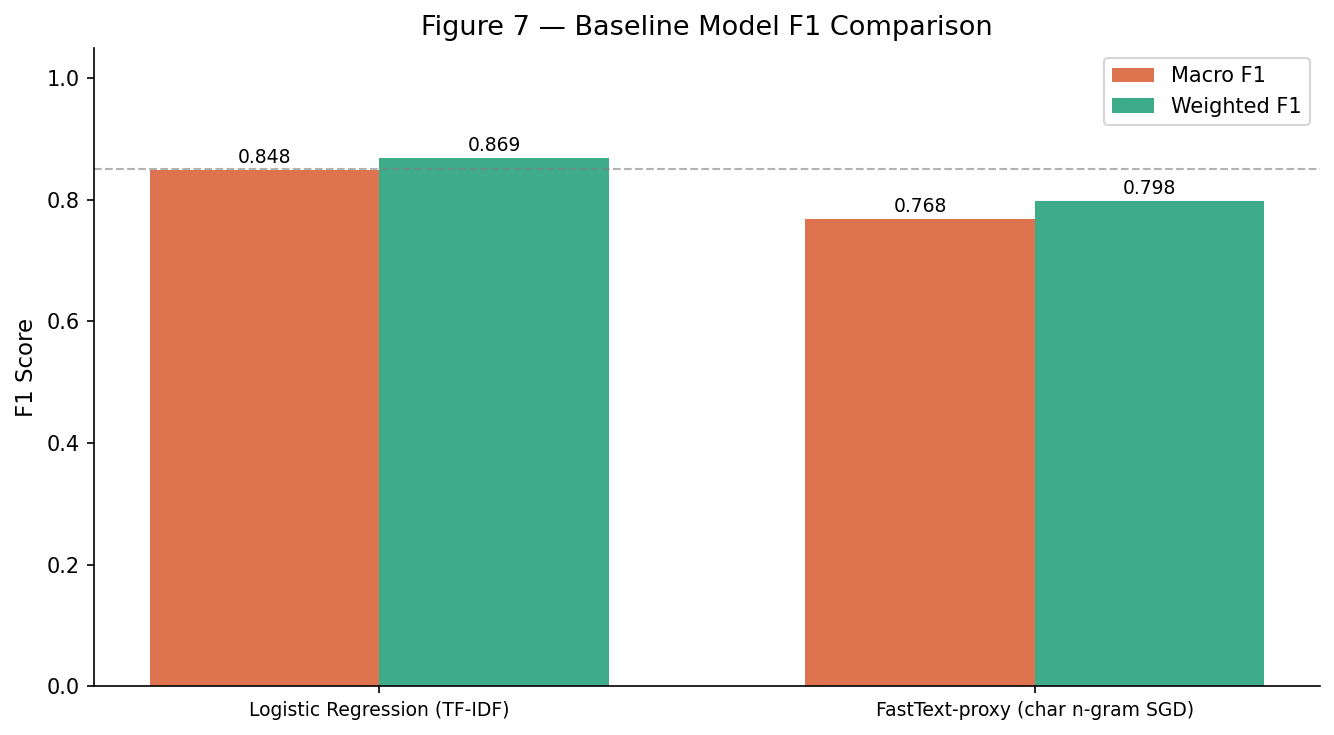

✓ Figure 7 saved

✓ Cell 12 complete — all baseline figures saved


In [ ]:
# Cell 12: Baseline Visualisations
# Figure 5: Confusion matrices
# Figure 6: Precision-Recall curves
# Figure 7: F1 comparison bar chart

from sklearn.metrics import ConfusionMatrixDisplay

# Figure 5: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, results in zip(axes, [lr_results, ft_results]):
    cm   = confusion_matrix(y_test, results["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-disaster","Disaster"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(results["model_name"], fontsize=10)
fig.suptitle("Figure 5 — Confusion Matrices (Test Set)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig5_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Figure 5 saved")

# Figure 6: PR curves
fig, ax = plt.subplots(figsize=(8, 6))
random_ap = float(y_test.mean())

for results, color, ls in [
    (lr_results, DISASTER_COLOR, "-"),
    (ft_results, NEUTRAL_COLOR,  "--"),
]:
    if results["y_proba"] is not None:
        prec, rec, _ = precision_recall_curve(y_test, results["y_proba"])
        ap = average_precision_score(y_test, results["y_proba"])
        ax.plot(rec, prec, color=color, lw=2, ls=ls,
                label=f"{results['model_name']} (AP={ap:.3f})")

ax.axhline(random_ap, color="grey", ls=":", lw=1.5,
           label=f"Random baseline (AP={random_ap:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Figure 6 — Precision-Recall Curves (Test Set)")
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
plt.tight_layout()
plt.savefig("fig6_pr_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Figure 6 saved")

# Figure 7: F1 comparison bar chart
model_names  = [lr_results["model_name"], ft_results["model_name"]]
macro_f1s    = [lr_results["macro_f1"],   ft_results["macro_f1"]]
weighted_f1s = [lr_results["weighted_f1"],ft_results["weighted_f1"]]
x = np.arange(len(model_names)); width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, macro_f1s,    width,
               label="Macro F1",    color=DISASTER_COLOR,   alpha=0.85)
bars2 = ax.bar(x + width/2, weighted_f1s, width,
               label="Weighted F1", color=NODISASTER_COLOR, alpha=0.85)
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel("F1 Score")
ax.set_title("Figure 7 — Baseline Model F1 Comparison")
ax.legend()
ax.axhline(0.85, color="grey", ls="--", lw=1, alpha=0.6,
           label="RQ1 binary F1 target (0.85)")
plt.tight_layout()
plt.savefig("fig7_f1_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✓ Figure 7 saved")

print("\n✓ Cell 12 complete — all baseline figures saved")

In [ ]:
# Cell 13: Save ALL Artifacts to Drive
#
# Files saved to Drive/Thesis_Stage1/:
#   df_clean.csv            — full preprocessed dataset (225K rows)
#   split_indices.json      — train/val/test index lists (seed=42)
#   tfidf_vectorizer.pkl    — fitted TF-IDF vectoriser
#   baseline_results.json   — F1 scores + dataset stats
#   fig1–fig7.png           — all thesis figures

print("=" * 55)
print("Saving Stage 1 artifacts to Drive")
print("=" * 55)

# 1. Full clean dataset
df_to_save = df[[
    "text", "clean_text", "label_binary",
    "label_type", "source", "event", "disaster_type"
]].copy()
df_to_save.to_csv("df_clean.csv", index=False)
save_to_drive("df_clean.csv", f"({len(df_to_save):,} rows)")

# 2. Split indices (CRITICAL — keeps Stage 2/3 on identical splits)
split_indices = {
    "train_idx" : list(map(int, X_train.index)),
    "val_idx"   : list(map(int, X_val.index)),
    "test_idx"  : list(map(int, X_test.index)),
}
with open("split_indices.json", "w") as f:
    json.dump(split_indices, f)
save_to_drive("split_indices.json",
    f"(train={len(split_indices['train_idx']):,}  "
    f"val={len(split_indices['val_idx']):,}  "
    f"test={len(split_indices['test_idx']):,})")

# 3. TF-IDF vectoriser
save_to_drive("tfidf_vectorizer.pkl")

# 4. Baseline results JSON
baseline_results = {
    "logistic_regression": {
        "binary_f1"   : lr_results["binary_f1"],
        "macro_f1"    : lr_results["macro_f1"],
        "weighted_f1" : lr_results["weighted_f1"],
        "train_time_s": lr_results["train_time"],
    },
    "fasttext_proxy": {
        "binary_f1"   : ft_results["binary_f1"],
        "macro_f1"    : ft_results["macro_f1"],
        "weighted_f1" : ft_results["weighted_f1"],
        "train_time_s": ft_results["train_time"],
    },
    "dataset_stats": {
        "total_rows"     : int(len(df)),
        "n_train"        : int(len(X_train)),
        "n_val"          : int(len(X_val)),
        "n_test"         : int(len(X_test)),
        "n_disaster"     : int(df["label_binary"].sum()),
        "n_non_disaster" : int((df["label_binary"]==0).sum()),
        "sources"        : df["source"].value_counts().to_dict(),
        "disaster_types" : df["disaster_type"].value_counts().to_dict(),
    }
}
with open("baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)
save_to_drive("baseline_results.json")

# 5. All figures
for fig_file in [f"fig{i}_{name}.png" for i, name in [
    (1,"class_distribution"), (2,"tweet_length"), (3,"label_types"),
    (4,"disaster_types"), (5,"confusion_matrices"),
    (6,"pr_curves"), (7,"f1_comparison"),
]]:
    if os.path.exists(fig_file):
        save_to_drive(fig_file)

# Final summary
print(f"""
{'='*65}
STAGE 1 COMPLETE — RESULTS SUMMARY
{'='*65}

Dataset:
  Total rows   : {len(df):,}
  Disaster (1) : {int(df['label_binary'].sum()):,}  ({df['label_binary'].mean()*100:.1f}%)
  Sources      : CrisisBench {int((df['source']=='crisisb').sum()):,}  +  HumAID {int((df['source']=='humaid').sum()):,}

Baseline Results (test set):
  {'Model':<35} {'Binary F1':>10} {'Macro F1':>10}
  {'-'*55}
  {'Logistic Regression (TF-IDF)':<35} {lr_results['binary_f1']:>10.4f} {lr_results['macro_f1']:>10.4f}
  {'FastText-proxy (char n-gram)':<35} {ft_results['binary_f1']:>10.4f} {ft_results['macro_f1']:>10.4f}

  RQ1 target: Binary F1 ≥ 0.85  |  Macro F1 ≥ 0.75
  LR result : {'✅ PASS' if lr_results['binary_f1'] >= 0.85 else '❌ FAIL'}

LOTO types available:
{df['disaster_type'].value_counts().to_string()}

All files saved to: {DRIVE_STAGE1_DIR}
  df_clean.csv            ← main artifact for Stage 2
  split_indices.json      ← train/val/test splits
  tfidf_vectorizer.pkl    ← TF-IDF vectoriser
  baseline_results.json   ← for thesis table
  fig1–fig7.png           ← thesis figures

Next: run Stage 2 notebook
  Tell Claude: 'Stage 2'
  Upload from Drive: df_clean.csv, split_indices.json
""")
print("✓ Stage 1 complete")

Saving Stage 1 artifacts to Drive
  ✓ df_clean.csv → Drive  (225,589 rows)
  ✓ split_indices.json → Drive  (train=157,906  val=33,844  test=33,839)
  ✓ tfidf_vectorizer.pkl → Drive  
  ✓ baseline_results.json → Drive  
  ✓ fig1_class_distribution.png → Drive  
  ✓ fig2_tweet_length.png → Drive  
  ✓ fig3_label_types.png → Drive  
  ✓ fig4_disaster_types.png → Drive  
  ✓ fig5_confusion_matrices.png → Drive  
  ✓ fig6_pr_curves.png → Drive  
  ✓ fig7_f1_comparison.png → Drive  

STAGE 1 COMPLETE — RESULTS SUMMARY
 
Dataset:
  Total rows   : 225,589
  Disaster (1) : 157,084  (69.6%)
  Sources      : CrisisBench 156,899  +  HumAID 68,690
 
Baseline Results (test set):
  Model                                Binary F1   Macro F1
  -------------------------------------------------------
  Logistic Regression (TF-IDF)            0.9002     0.8481
  FastText-proxy (char n-gram)            0.8449     0.7683
 
  RQ1 target: Binary F1 ≥ 0.85  |  Macro F1 ≥ 0.75
  LR result : ✅ PASS
 
LOTO types a